## Análisis Univariable

### By:
Karen Ninco

### Date:
2026-08-20

### Description:

#### Requerimiento
Realizar un análisis exploratorio de datos (EDA) para caracterizar los datos disponibles del proyecto, comenzando por el análisis univariable de cada atributo.

Tomar como ejemplo los pasos de: https://joserzapata.github.io/post/ciencia-datos-proyecto-python/3-analysis/

Para cada variable se estudia: nombre, tipo de dato, porcentaje de valores nulos, valores duplicados, presencia de ruido o valores atípicos, y descripción estadística (tendencia central y dispersión para las numéricas; distribución de frecuencias para las categóricas).

#### Entregables:
Notebook con el análisis univariable de los datos.
Se debe realizar un Pull request para ingresar el notebook a la rama main, con mínimo 1 revisión y que pase los checks de CI/CD.


## 📚 Import libraries

In [2]:
# base libraries for data science
import sys
from pathlib import Path

import pandas as pd

pd.set_option("display.float_format", "{:.2f}".format)

In [3]:
# print library version for reproducibility

print("Python version: ", sys.version)
print("Pandas version: ", pd.__version__)

Python version:  3.12.3 (main, Jun 19 2026, 12:46:00) [GCC 13.3.0]
Pandas version:  3.0.5


## 💾 Load data

In [4]:
# Load data
DATA_DIR = Path.cwd().resolve().parents[1] / "data" / "02_intermediate"

corazon_df = pd.read_parquet(DATA_DIR / "corazon_clean.parquet")

## 📊 Data description

In [5]:
corazon_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3030 entries, 0 to 3029
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   age         2998 non-null   float64 
 1   sex         2966 non-null   category
 2   chest_pain  2944 non-null   category
 3   rest_bp     2947 non-null   float64 
 4   chol        2943 non-null   float64 
 5   fbs         2933 non-null   boolean 
 6   rest_ecg    2832 non-null   category
 7   max_hr      2858 non-null   Int16   
 8   exang       2877 non-null   boolean 
 9   old_peak    2878 non-null   float64 
 10  slope       2878 non-null   category
 11  ca          2867 non-null   Int8    
 12  thal        2900 non-null   category
 13  disease     2919 non-null   boolean 
dtypes: Int16(1), Int8(1), boolean(3), category(5), float64(4)
memory usage: 142.5 KB


In [6]:
# size of the dataframe
corazon_df.shape

(3030, 14)

In [7]:
# sample of the dataframe
corazon_df.sample(5)

,age,sex,chest_pain,rest_bp,chol,fbs,rest_ecg,max_hr,exang,old_peak,slope,ca,thal,disease
2407,58.00,Female,asymptomatic,170.00,225.00,True,left ventricular hypertrophy,146,True,2.80,2,2,fixed,True
439,70.00,Male,asymptomatic,145.00,174.00,False,normal,125,True,2.60,3,0,reversable,True
1037,44.00,Male,nontypical,120.00,220.00,False,normal,170,False,0.00,1,0,normal,False
3013,58.00,Female,asymptomatic,170.00,225.00,True,left ventricular hypertrophy,146,True,2.80,2,2,fixed,True
1756,41.00,Female,nontypical,126.00,306.00,False,normal,163,False,0.00,1,0,normal,False


In [8]:
# Number of duplicated rows
corazon_df.duplicated().sum()

np.int64(2462)

In [9]:
# Number of missing values
corazon_df.isnull().sum()

age            32
sex            64
chest_pain     86
rest_bp        83
chol           87
fbs            97
rest_ecg      198
max_hr        172
exang         153
old_peak      152
slope         152
ca            163
thal          130
disease       111
dtype: int64

Target Variable = disease

### General statistics of the data set

### Numerical variables

In [10]:
corazon_df.describe()

,age,rest_bp,chol,max_hr,old_peak,ca
count,2998.00,2947.00,2943.00,2858.00,2878.00,2867.00
mean,54.46,131.62,246.72,149.56,1.04,0.67
std,9.02,17.57,51.60,22.88,1.16,0.94
min,29.00,94.00,126.00,71.00,0.00,0.00
25%,48.00,120.00,211.00,133.00,0.00,0.00
50%,56.00,130.00,241.00,153.00,0.80,0.00
75%,61.00,140.00,275.00,166.00,1.60,1.00
max,77.00,200.00,564.00,202.00,6.20,3.00


### Categorical variables

In [11]:
# categorical columns description
corazon_df.describe(include="category")

,sex,chest_pain,rest_ecg,slope,thal
count,2966,2944,2832,2878,2900
unique,2,4,3,3,3
top,Male,asymptomatic,normal,1,normal
freq,2017,1394,1409,1353,1599


## 📈 Univariate Analysis

### Target Variable

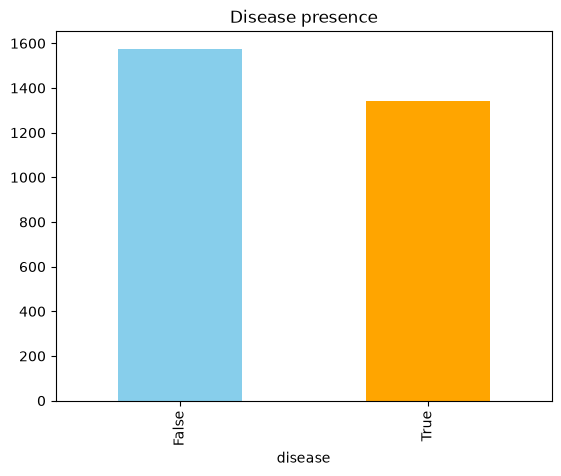

In [12]:
corazon_df["disease"].value_counts().plot(
    kind="bar", color=["skyblue", "orange"], title="Disease presence"
);

In [13]:
corazon_df["disease"].value_counts()

disease
False    1576
True     1343
Name: count, dtype: Int64

### Numerical Variables

In [14]:
# list of the numerical columns
numerical_columns = list(corazon_df.select_dtypes(include=["number"]).columns)
numerical_columns

['age', 'rest_bp', 'chol', 'max_hr', 'old_peak', 'ca']

### age

In [15]:
column = "age"
corazon_df[column].describe()

count   2998.00
mean      54.46
std        9.02
min       29.00
25%       48.00
50%       56.00
75%       61.00
max       77.00
Name: age, dtype: float64

In [16]:
# number of unique values
corazon_df[column].nunique()

41

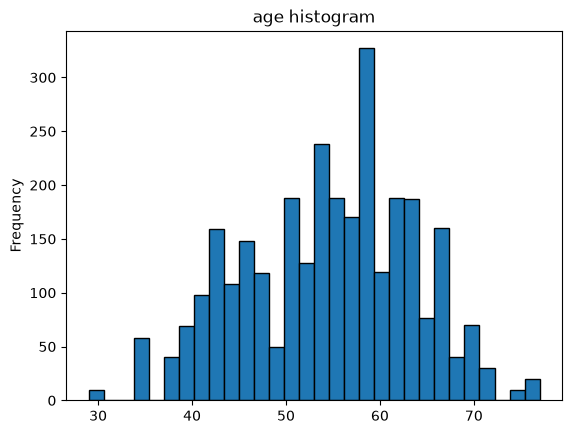

In [17]:
corazon_df[column].plot(kind="hist", bins=30, edgecolor="black", title=f"{column} histogram");

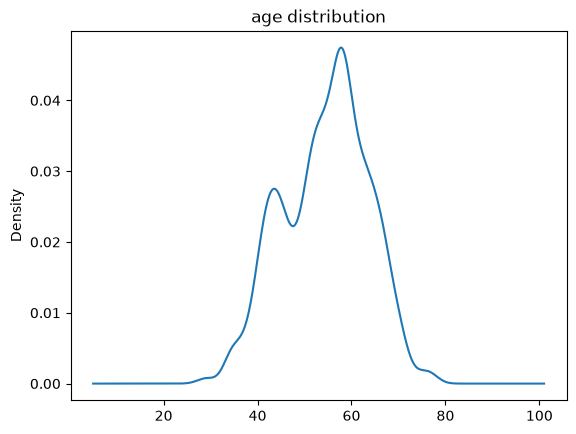

In [18]:
corazon_df[column].plot(kind="density", title=f"{column} distribution");

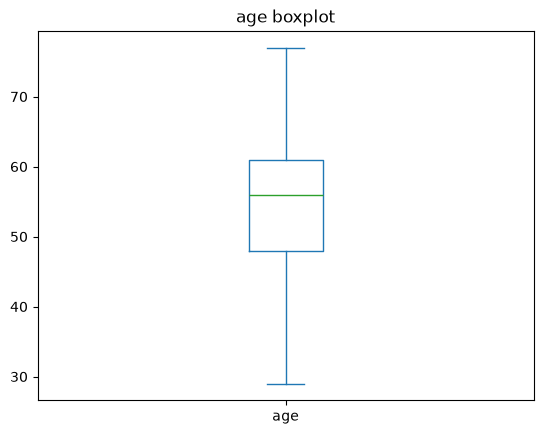

In [19]:
corazon_df[column].plot(kind="box", title=f"{column} boxplot");

#### rest_bp

In [20]:
column = "rest_bp"
corazon_df[column].describe()

count   2947.00
mean     131.62
std       17.57
min       94.00
25%      120.00
50%      130.00
75%      140.00
max      200.00
Name: rest_bp, dtype: float64

In [21]:
corazon_df[column].nunique()

50

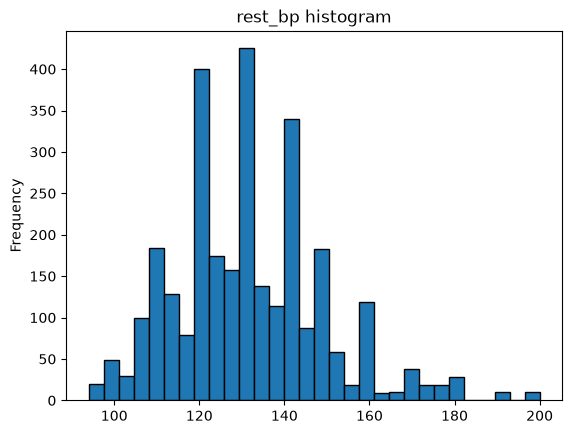

In [22]:
corazon_df[column].plot(kind="hist", bins=30, edgecolor="black", title=f"{column} histogram");

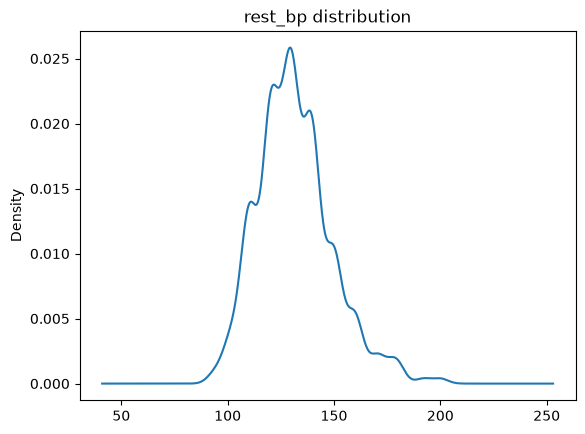

In [23]:
corazon_df[column].plot(kind="density", title=f"{column} distribution");

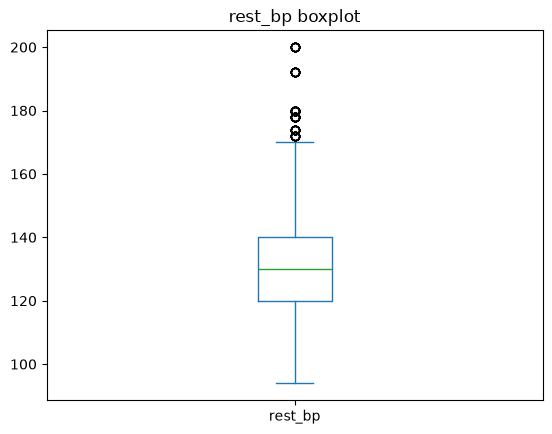

In [24]:
corazon_df[column].plot(kind="box", title=f"{column} boxplot");

#### chol

In [25]:
column = "chol"
corazon_df[column].describe()

count   2943.00
mean     246.72
std       51.60
min      126.00
25%      211.00
50%      241.00
75%      275.00
max      564.00
Name: chol, dtype: float64

In [26]:
corazon_df[column].nunique()

152

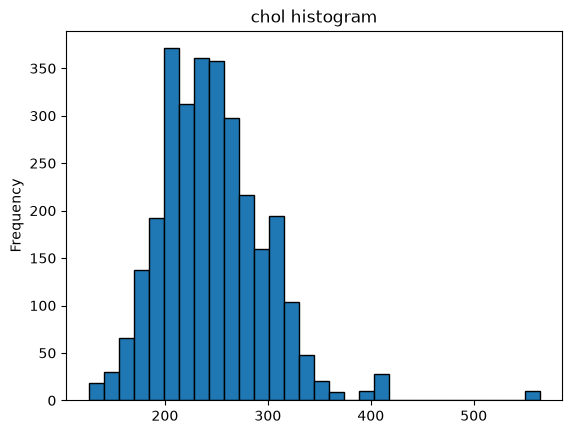

In [27]:
corazon_df[column].plot(kind="hist", bins=30, edgecolor="black", title=f"{column} histogram");

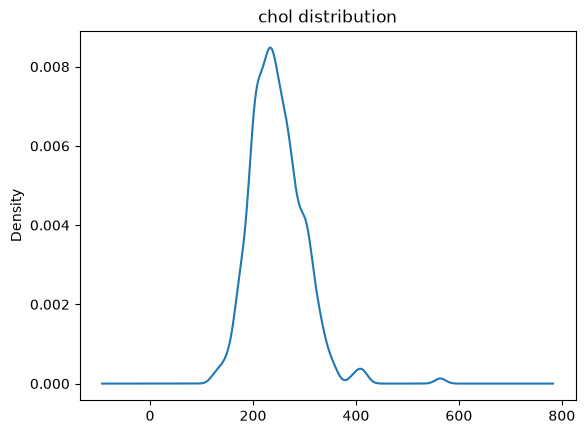

In [28]:
corazon_df[column].plot(kind="density", title=f"{column} distribution");

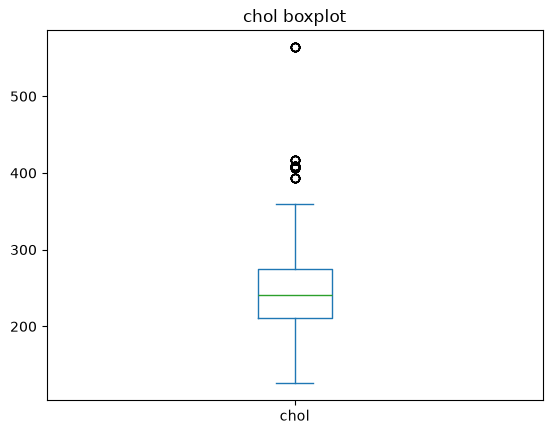

In [29]:
corazon_df[column].plot(kind="box", title=f"{column} boxplot");

#### old_peak

In [30]:
column = "old_peak"
corazon_df[column].describe()

count   2878.00
mean       1.04
std        1.16
min        0.00
25%        0.00
50%        0.80
75%        1.60
max        6.20
Name: old_peak, dtype: float64

In [31]:
corazon_df[column].nunique()

40

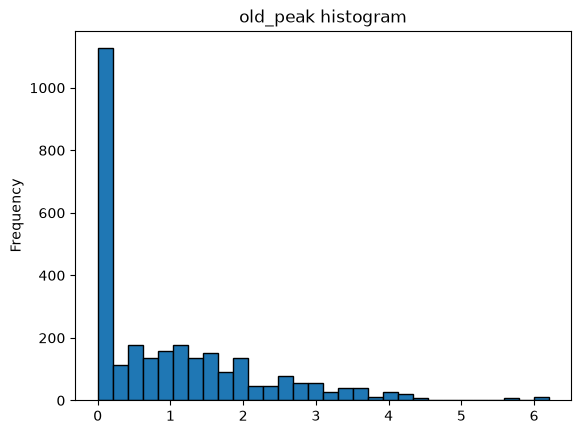

In [32]:
corazon_df[column].plot(kind="hist", bins=30, edgecolor="black", title=f"{column} histogram");

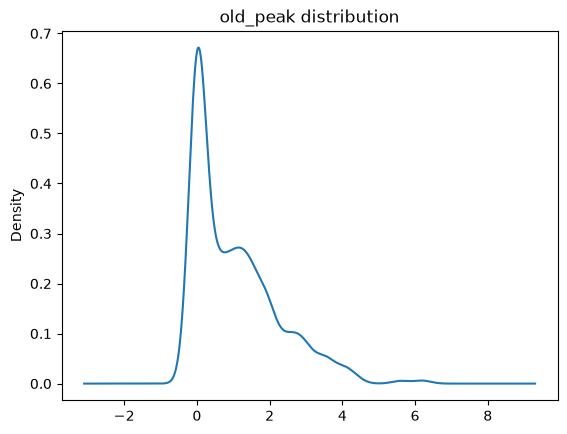

In [33]:
corazon_df[column].plot(kind="density", title=f"{column} distribution");

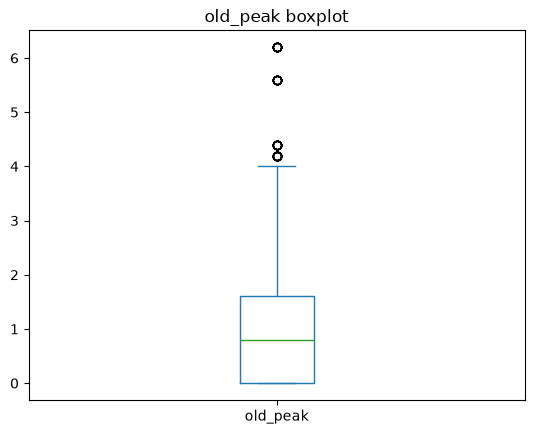

In [34]:
corazon_df[column].plot(kind="box", title=f"{column} boxplot");

#### max_hr

In [35]:
column = "max_hr"
corazon_df[column].describe()

count   2858.00
mean     149.56
std       22.88
min       71.00
25%      133.00
50%      153.00
75%      166.00
max      202.00
Name: max_hr, dtype: Float64

In [36]:
corazon_df[column].nunique()

91

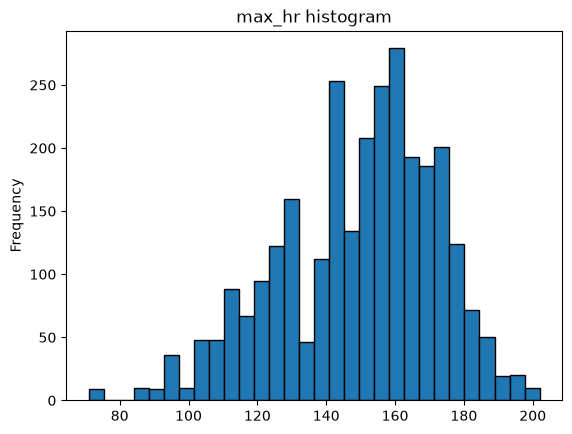

In [37]:
corazon_df[column].plot(kind="hist", bins=30, edgecolor="black", title=f"{column} histogram");

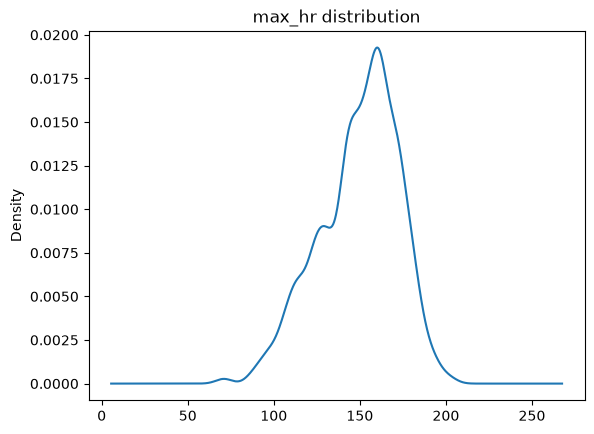

In [38]:
corazon_df[column].plot(kind="density", title=f"{column} distribution");

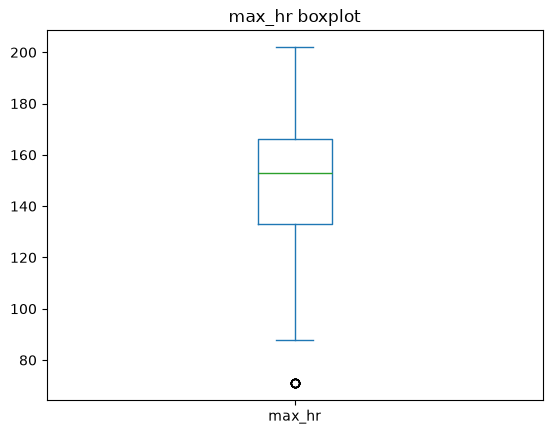

In [39]:
corazon_df[column].plot(kind="box", title=f"{column} boxplot");

#### ca

In [40]:
column = "ca"
corazon_df[column].describe()

count   2867.00
mean       0.67
std        0.94
min        0.00
25%        0.00
50%        0.00
75%        1.00
max        3.00
Name: ca, dtype: Float64

In [41]:
corazon_df[column].nunique()

4

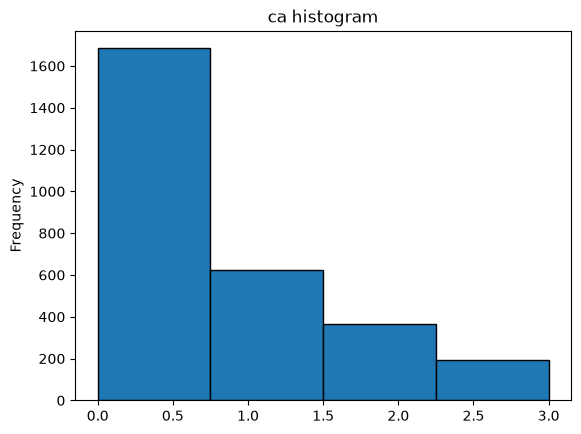

In [42]:
corazon_df[column].plot(kind="hist", bins=4, edgecolor="black", title=f"{column} histogram");

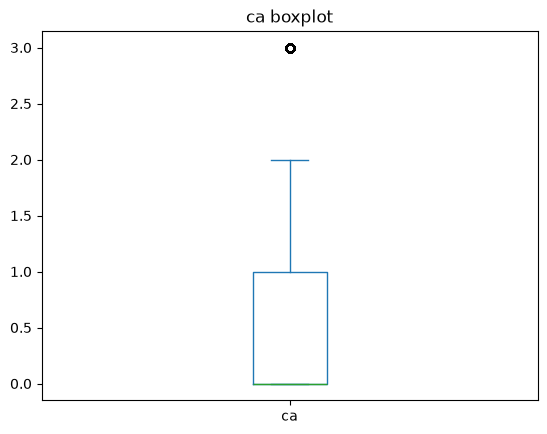

In [43]:
corazon_df[column].plot(kind="box", title=f"{column} boxplot");

### Categorical Variables

In [73]:
# list of the categorical columns
# fbs and exang are boolean dtype but are conceptually categorical (nominal), so we add them manually
categorical_columns = [
    *corazon_df.select_dtypes(include=["category"]).columns,
    "fbs",
    "exang",
]
categorical_columns

['sex', 'chest_pain', 'rest_ecg', 'slope', 'thal', 'fbs', 'exang']

#### sex

In [45]:
column = "sex"
corazon_df[column].describe()

count     2966
unique       2
top       Male
freq      2017
Name: sex, dtype: object

In [46]:
corazon_df[column].unique()

['Male', 'Female', NaN]
Categories (2, str): ['Female', 'Male']

In [47]:
corazon_df[column].value_counts()

sex
Male      2017
Female     949
Name: count, dtype: int64

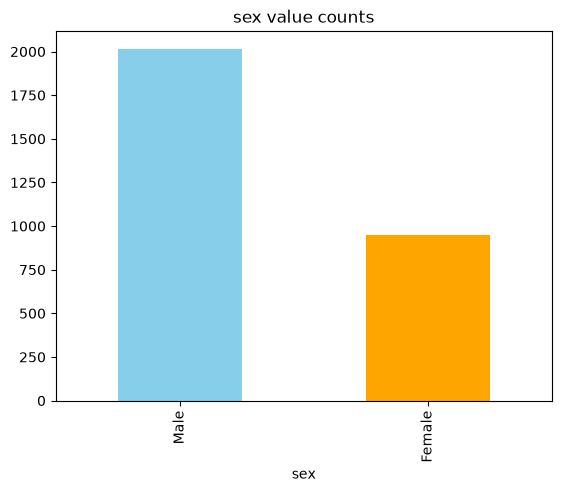

In [48]:
corazon_df[column].value_counts().plot(
    kind="bar", color=["skyblue", "orange"], title=f"{column} value counts"
);

#### chest_pain

In [49]:
column = "chest_pain"
corazon_df[column].describe()

count             2944
unique               4
top       asymptomatic
freq              1394
Name: chest_pain, dtype: object

In [50]:
corazon_df[column].unique()

['typical', 'asymptomatic', 'nonanginal', 'nontypical', NaN]
Categories (4, str): ['asymptomatic', 'nonanginal', 'nontypical', 'typical']

In [51]:
corazon_df[column].value_counts()

chest_pain
asymptomatic    1394
nonanginal       840
nontypical       486
typical          224
Name: count, dtype: int64

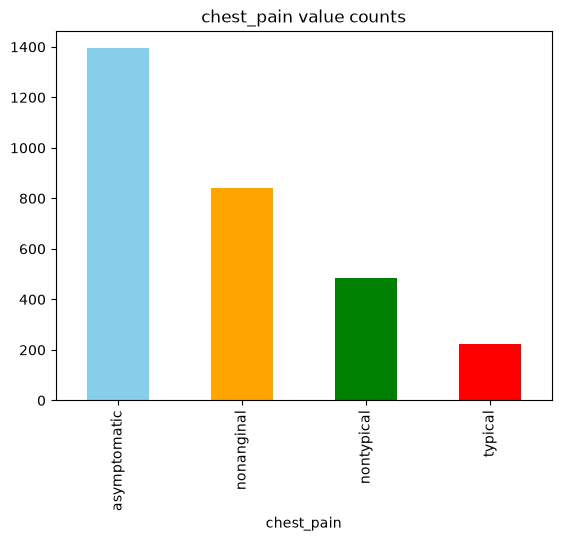

In [52]:
corazon_df[column].value_counts().plot(
    kind="bar",
    color=["skyblue", "orange", "green", "red"],
    title=f"{column} value counts",
);

#### rest_ecg

In [53]:
column = "rest_ecg"
corazon_df[column].describe()

count       2832
unique         3
top       normal
freq        1409
Name: rest_ecg, dtype: object

In [54]:
corazon_df[column].unique()

['left ventricular hypertrophy', 'normal', 'ST-T wave abnormality', NaN]
Categories (3, str): ['ST-T wave abnormality', 'left ventricular hypertrophy', 'normal']

In [55]:
corazon_df[column].value_counts()

rest_ecg
normal                          1409
left ventricular hypertrophy    1387
ST-T wave abnormality             36
Name: count, dtype: int64

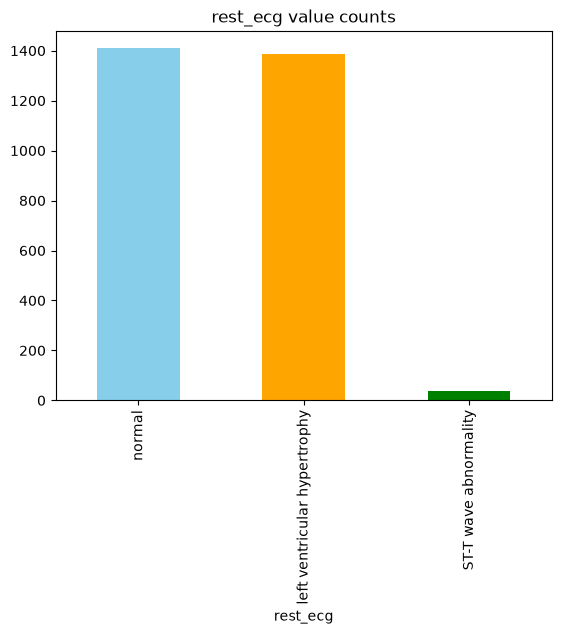

In [56]:
corazon_df[column].value_counts().plot(
    kind="bar", color=["skyblue", "orange", "green"], title=f"{column} value counts"
);

#### slope

In [57]:
column = "slope"
corazon_df[column].describe()

count     2878
unique       3
top          1
freq      1353
Name: slope, dtype: object

In [58]:
corazon_df[column].unique()

['3', '2', '1', NaN]
Categories (3, str): ['1' < '2' < '3']

In [59]:
corazon_df[column].value_counts()

slope
1    1353
2    1323
3     202
Name: count, dtype: int64

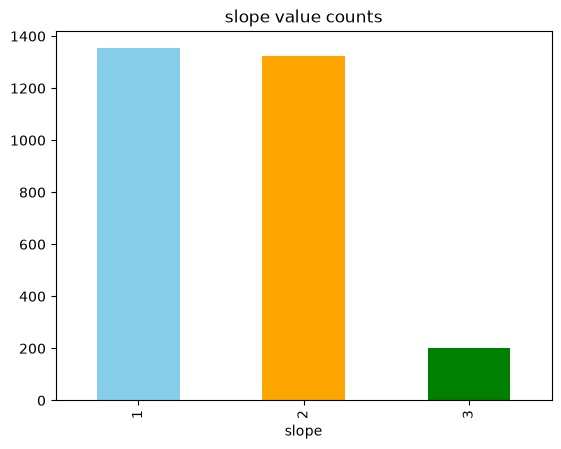

In [60]:
corazon_df[column].value_counts().plot(
    kind="bar", color=["skyblue", "orange", "green"], title=f"{column} value counts"
);

#### thal

In [61]:
column = "thal"
corazon_df[column].describe()

count       2900
unique         3
top       normal
freq        1599
Name: thal, dtype: object

In [62]:
corazon_df[column].unique()

['fixed', 'normal', 'reversable', NaN]
Categories (3, str): ['fixed', 'normal', 'reversable']

In [63]:
corazon_df[column].value_counts()

thal
normal        1599
reversable    1129
fixed          172
Name: count, dtype: int64

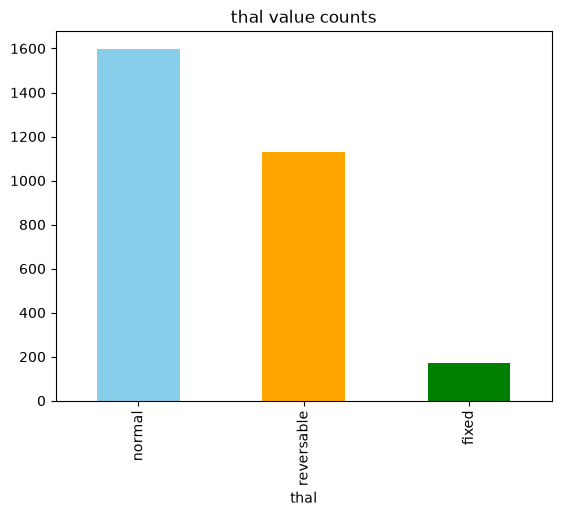

In [64]:
corazon_df[column].value_counts().plot(
    kind="bar", color=["skyblue", "orange", "green"], title=f"{column} value counts"
);

#### fbs

In [65]:
column = "fbs"
corazon_df[column].describe()

count      2933
unique        2
top       False
freq       2498
Name: fbs, dtype: object

In [66]:
corazon_df[column].unique()

<BooleanArray>
[True, False, <NA>]
Length: 3, dtype: boolean

In [67]:
corazon_df[column].value_counts()

fbs
False    2498
True      435
Name: count, dtype: Int64

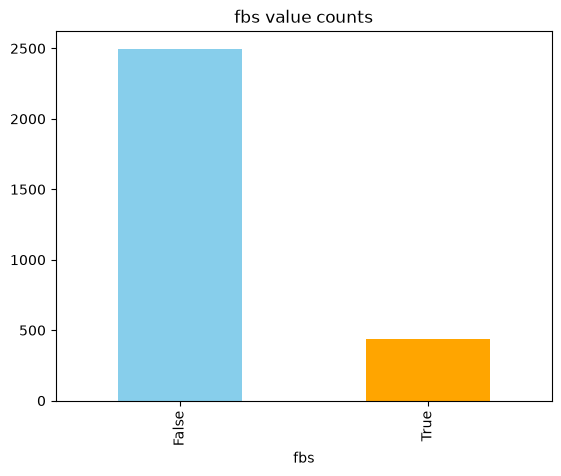

In [68]:
corazon_df[column].value_counts().plot(
    kind="bar", color=["skyblue", "orange"], title=f"{column} value counts"
);

#### exang

In [69]:
column = "exang"
corazon_df[column].describe()

count      2877
unique        2
top       False
freq       1929
Name: exang, dtype: object

In [70]:
corazon_df[column].unique()

<BooleanArray>
[False, True, <NA>]
Length: 3, dtype: boolean

In [71]:
corazon_df[column].value_counts()

exang
False    1929
True      948
Name: count, dtype: Int64

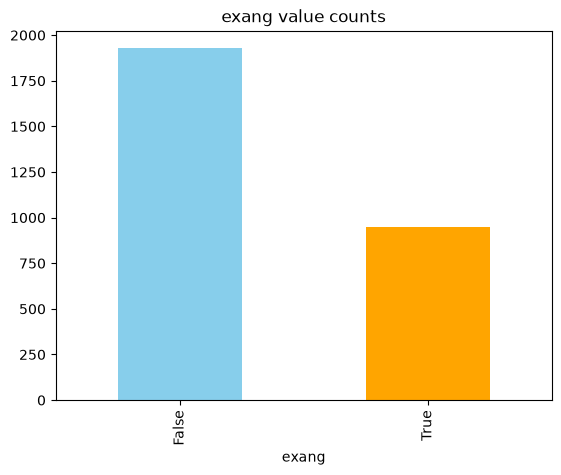

In [72]:
corazon_df[column].value_counts().plot(
    kind="bar", color=["skyblue", "orange"], title=f"{column} value counts"
);

## 📊 Analysis of Results and Conclusions 

### Dataset Overview

El dataset contiene 3030 pacientes con 14 variables (13 predictoras y la variable objetivo `disease`). Todas las columnas presentan valores nulos, pero ninguna supera el ~7% de datos faltantes (`rest_ecg` es la que más tiene, con 198), lo cual respalda la decisión tomada en el notebook anterior de no eliminar ninguna columna por exceso de nulos. Estos nulos deberán tratarse en la etapa de preparación de datos.

**Nota importante:** se detectaron 2462 filas completamente duplicadas sobre un total de 3030 (~81%), lo que sugiere que el dataset contiene alrededor de 568 registros de pacientes únicos, repetidos varias veces. Como el dataset no incluye un identificador único de paciente, no es posible confirmarlo con certeza absoluta; sin embargo, dado que la coincidencia exacta en las 14 variables (incluyendo varias numéricas continuas) es estadísticamente muy poco probable entre personas distintas, es razonable interpretar estas filas como duplicados reales y no como pacientes diferentes con valores casualmente iguales. Este hallazgo deberá tenerse en cuenta en la etapa de preparación de datos, especialmente al dividir el dataset en entrenamiento y prueba, para evitar fuga de información (data leakage).

### Target Variable: `disease`

De los 2919 registros no nulos, 1576 (54%) no presentan enfermedad y 1343 (46%) sí la presentan. El dataset está relativamente balanceado, sin el desbalance severo que suele complicar el entrenamiento de modelos de clasificación.

### Numerical Variables

**Age:** Promedio de 54.46 años (mediana 56), desviación estándar 9.02, rango 29-77. Distribución en forma de campana, concentrada entre 45 y 70 años, sin valores atípicos extremos. Esto indica que la mayoría de los pacientes son adultos de edad media a mayor.

**Rest_bp (presión arterial en reposo):** Promedio 131.62 mmHg (mediana 130), desviación estándar 17.57, con valores atípicos por encima de 170 mmHg (hasta 200). Indica que la mayoría tiene presión normal-alta (110-140), con un grupo pequeño notablemente elevado.

**Chol (colesterol):** Promedio 246.72 (mediana 241), desviación estándar 51.60, con valores atípicos por encima de 390 (caso extremo: 564). El colesterol típico está entre 200 y 275, pero algunos pacientes presentan niveles muy altos.

**Old_peak:** La variable con mayor asimetría: más de 1100 registros en 0, cola larga hasta 6.20; el promedio (1.04) supera claramente la mediana (0.80). Indica que la mayoría no presenta depresión del ST inducida por ejercicio, mientras un grupo minoritario sí, con valores altos.

**Max_hr (frecuencia cardíaca máxima):** Promedio 149.56 (mediana 153), desviación estándar 22.88, distribución razonablemente simétrica entre 140 y 180. Indica frecuencias máximas típicas para la mayoría, sin comportamientos extremos.

**Ca (vasos principales coloreados):** Variable discreta (0 a 3); la mayoría (~1700) tiene valor 0, y la frecuencia baja progresivamente hasta 3 (marcado como atípico). Indica que tener vasos afectados es poco común en este grupo.

### Categorical Variables

**Sex:** Predominan los hombres (2017, ~68%) sobre las mujeres (949, ~32%) — relevante porque el riesgo cardíaco varía según el sexo.

**Chest_pain:** El tipo más frecuente es "asymptomatic" (1394, ~47%), seguido de "nonanginal" (840), "nontypical" (486) y "typical" (224).

**Rest_ecg:** "Normal" (1409) y "left ventricular hypertrophy" (1387) son casi igual de frecuentes; "ST-T wave abnormality" es raro (36 casos).

**Slope:** Las categorías 1 (1353) y 2 (1323) predominan sobre la 3 (202).

**Thal:** Predomina "normal" (1599, ~55%), seguido de "reversable" (1129) y "fixed" (172).

**Fbs:** La mayoría no presenta glucemia alta en ayunas (False: 2498, ~85%) frente a quienes sí (True: 435, ~15%).

**Exang:** La mayoría no presenta angina inducida por ejercicio (False: 1929, ~67%) frente a quienes sí (True: 948, ~33%).

### Key Takeaways

- **Variable objetivo relativamente balanceada:** 54% sin enfermedad vs. 46% con enfermedad.
- **Valores atípicos en variables numéricas:** `chol`, `rest_bp` y `old_peak` presentan casos extremos a revisar en la preparación de datos.
- **Old_peak fuertemente asimétrica:** más de un tercio de los pacientes tiene el valor mínimo (0).
- **Desbalance de sexo:** predominan los hombres (68%) sobre las mujeres (32%).
- **Fbs y exang desbalanceadas:** la mayoría de los pacientes no presenta estas condiciones.
- **Estrategia de datos faltantes:** ningún porcentaje de nulos es crítico; se podrán tratar con imputación en la siguiente etapa.